# Predictive Maintenance — Failure Mode Counts

Counting how often each failure mode (TWF, HDF, PWF, OSF, RNF) occurs in the dataset, to support the case that a binary `Machine failure` label hides useful diagnostic detail.

In [1]:
import pandas as pd

df = pd.read_csv('./data/predictive_maintenance.csv')
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

mode_counts = df[failure_modes].sum().sort_values(ascending=False)
total_failures = df['Machine failure'].sum()
overlap = (df[failure_modes].sum(axis=1) > 1).sum()

print(f"Total rows: {len(df)}")
print(f"Total Machine failure = 1: {total_failures}")
print(f"Rows with more than one failure mode active: {overlap}")
mode_counts

Total rows: 10000
Total Machine failure = 1: 339
Rows with more than one failure mode active: 24


HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

<Axes: title={'center': 'Failure Mode Counts'}>

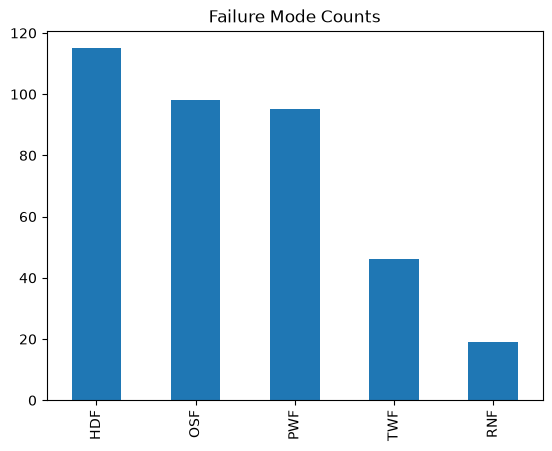

In [3]:
mode_counts.plot(kind='bar', title='Failure Mode Counts')

# Dataset Overview

### 1-Minute Dataset Overview: Milling Machine Predictive Maintenance

This dataset captures 10,000 synthetic operational cycles of a computer numerical control (CNC) milling machine. It models real-time telemetry alongside specific wear mechanics:

* **Type**: Product quality grade (`L` = Low/50%, `M` = Medium/30%, `H` = High/20%), which dictates machining tolerances and feed rates.
* **Air temperature [K]**: Ambient factory floor temperature around the enclosure.
* **Process temperature [K]**: Contact-zone thermal output during active cutting.
* **Rotational speed [rpm]**: Spindle rotation frequency; lower speeds with high loads cause heat buildup, while overspeeding accelerates wear.
* **Torque [Nm]**: Torsional resistance on the spindle drive motor.
* **Tool wear [min]**: Cumulative cutting duration on the currently installed mill bit.
* **Machine failure**: Binary target (0 = nominal operation, 1 = failure event). The dataset is heavily imbalanced: only 339 runs (~3.4%) result in downtime.
* **Failure Modes (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`)**: Operational flags indicating tool wear-out, heat dissipation limits, electrical power mismatch, overstrain, or random hardware breakdown.

**Data Cleanliness**: The dataset is complete and well-structured, with zero missing null values and consistent SI-derived units. No imputation is necessary; processing can proceed straight to sensor normalization and addressing class imbalance.

In [4]:
import pandas as pd


class MaintenanceDataset:
    """Manages the AI4I 2020 predictive maintenance data pipeline and views."""

    def __init__(self, file_path: str = "data/predictive_maintenance.csv"):
        """Loads machine telemetry and initializes standard sensor column definitions."""
        # The CSV headers have no units; add them so every section uses the agreed "[K]"-style names
        self.raw_dataframe = pd.read_csv(file_path).rename(
            columns={
                "Air temperature": "Air temperature [K]",
                "Process temperature": "Process temperature [K]",
                "Rotational speed": "Rotational speed [rpm]",
                "Torque": "Torque [Nm]",
                "Tool wear": "Tool wear [min]",
            }
        )
        self.sensor_column_names = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]

    @property
    def raw_data(self) -> pd.DataFrame:
        """Returns the complete, unmodified machine telemetry dataframe."""
        return self.raw_dataframe

    @property
    def sensors(self) -> pd.DataFrame:
        """Returns the continuous numeric sensor measurement columns only."""
        return self.raw_dataframe[self.sensor_column_names]

    @property
    def healthy(self) -> pd.DataFrame:
        """Returns records of runs operating without machine failure."""
        return self.raw_dataframe[self.raw_dataframe["Machine failure"] == 0]

    @property
    def failed(self) -> pd.DataFrame:
        """Returns records where machine failure occurred."""
        return self.raw_dataframe[self.raw_dataframe["Machine failure"] == 1]

    def overview(self) -> pd.DataFrame:
        """Returns a combined tabular breakdown of types, missing counts, and shape."""
        overview_table = pd.DataFrame(
            {
                "data_type": self.raw_dataframe.dtypes,
                "missing_values": self.raw_dataframe.isnull().sum(),
                "distinct values": self.raw_dataframe.nunique(),
            }
        )
        print(f"Total Rows: {self.raw_dataframe.shape[0]}, Total Columns: {self.raw_dataframe.shape[1]}")
        return overview_table

In [5]:
# Instantiate the dataset object for use across downstream tasks (Person B & C)
maintenance_dataset = MaintenanceDataset("data/predictive_maintenance.csv")

# Quick inspection of structure, missing values, and property slices
maintenance_dataset.overview()

Total Rows: 10000, Total Columns: 12


,data_type,missing_values,distinct values
Type,str,0,3
Air temperature [K],float64,0,93
Process temperature [K],float64,0,82
Rotational speed [rpm],int64,0,941
Torque [Nm],float64,0,577
Tool wear [min],int64,0,246
Machine failure,int64,0,2
TWF,int64,0,2
HDF,int64,0,2
PWF,int64,0,2


# Central Tendency and Spread

**Author: Person B**


## Use case summary (50 words)

Manufacturers want to predict machine failure before it happens using
sensor data (temperature, speed, torque, tool wear). By analyzing these
readings statistically, maintenance teams can identify warning patterns,
schedule repairs proactively, avoid unplanned downtime, and reduce costs,
instead of reacting only after equipment already breaks down unexpectedly.

In [6]:
# Reusing Person A's loader instead of reading the CSV a second time.
df = maintenance_dataset.raw_data
df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
class DescriptiveStats:
    """Computes central tendency and spread statistics for the maintenance dataset."""

    def __init__(self, df):
        """Inits DescriptiveStats with the source dataframe.

        Args:
            df: pandas DataFrame containing the machine-run records.
        """
        self.df = df
        self.numeric_cols = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]

    def central_tendency(self):
        """Computes mean, median, and skewness for each numeric column.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'mean', 'median', and 'skew'.
        """
        rows = {}
        for col in self.numeric_cols:
            rows[col] = {
                "mean": self.df[col].mean(),
                "median": self.df[col].median(),
                "skew": self.df[col].skew(),
            }
        return pd.DataFrame(rows).T

    def categorical_modes(self):
        """Computes the mode of the categorical columns and its frequency.

        Returns:
            A pandas DataFrame with the mode value and count for
            'Type' and 'Machine failure'.
        """
        cat_cols = ["Type", "Machine failure"]
        rows = {}
        for col in cat_cols:
            mode_value = self.df[col].mode()[0]
            mode_count = (self.df[col] == mode_value).sum()
            rows[col] = {"mode": mode_value, "count": mode_count}
        return pd.DataFrame(rows).T

    def spread(self):
        """Computes variance, standard deviation, and coefficient of variation.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'variance', 'std', and 'cv' (std / mean).
        """
        rows = {}
        for col in self.numeric_cols:
            var = self.df[col].var()
            std = self.df[col].std()
            mean = self.df[col].mean()
            rows[col] = {
                "variance": var,
                "std": std,
                "cv": std / mean,
            }
        return pd.DataFrame(rows).T

    def quartiles(self):
        """Computes Q1, median, Q3, max, and IQR for each numeric column.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'q1', 'median', 'q3', 'max', and 'iqr'.
        """
        rows = {}
        for col in self.numeric_cols:
            q1 = self.df[col].quantile(0.25)
            q2 = self.df[col].quantile(0.50)
            q3 = self.df[col].quantile(0.75)
            rows[col] = {
                "q1": q1,
                "median": q2,
                "q3": q3,
                "max": self.df[col].max(),
                "iqr": q3 - q1,
            }
        return pd.DataFrame(rows).T

In [8]:
stats = DescriptiveStats(df)
central_table = stats.central_tendency()
central_table

,mean,median,skew
Air temperature [K],300.00493,300.1,0.114274
Process temperature [K],310.00556,310.1,0.015027
Rotational speed [rpm],1538.77610,1503.0,1.993171
Torque [Nm],39.98691,40.1,-0.009517
Tool wear [min],107.95100,108.0,0.027292


In [9]:
mode_table = stats.categorical_modes()
mode_table

,mode,count
Type,L,6000
Machine failure,0,9661


In [10]:
spread_table = stats.spread()
spread_table

,variance,std,cv
Air temperature [K],4.001035,2.000259,0.006667
Process temperature [K],2.201467,1.483734,0.004786
Rotational speed [rpm],32142.787047,179.284096,0.116511
Torque [Nm],99.379640,9.968934,0.249305
Tool wear [min],4051.850384,63.654147,0.589658


In [11]:
quartile_table = stats.quartiles()
quartile_table

,q1,median,q3,max,iqr
Air temperature [K],298.3,300.1,301.5,304.5,3.2
Process temperature [K],308.8,310.1,311.1,313.8,2.3
Rotational speed [rpm],1423.0,1503.0,1612.0,2886.0,189.0
Torque [Nm],33.2,40.1,46.8,76.6,13.6
Tool wear [min],53.0,108.0,162.0,253.0,109.0


### Mean vs. median: which one do you trust?

The mean is the right summary when a distribution is roughly symmetric,
because every value pulls it equally in both directions. Once a column has
noticeable skew — a long tail stretching one way — the mean gets dragged
toward that tail, so the median (the middle value, immune to extreme
outliers) becomes the more trustworthy "typical value." Check the skew
column above: anything with `|skew| > 0.5` should be summarized with the
median, not the mean.

### Why mode fits the categorical columns

Mean and median require values that can be ordered and averaged
numerically. `Type` (L/M/H) and `Machine failure` (0/1) are categories, not
quantities — averaging "0.034" failures per row is not a meaningful
statement about a single machine run. The mode simply answers "which
category shows up most often," which is the only central-tendency question
that makes sense for labels.

### Which columns are most/least variable?

Coefficient of variation (CV = std / mean) lets us compare variability
*across* columns that are measured in completely different units and
scales, which raw standard deviation cannot do. A column with a small CV
(like the temperature readings) is tightly controlled by the process; a
column with a larger CV (like torque or tool wear) swings more relative to
its own average, meaning it carries more day-to-day variation for the
process to manage.

# Visualization and Numerical Summary (Challenge 7)

**Author: Person C**

**Bottom line: failures are not random.** They cluster at high torque, low spindle speed and worn tools, and most have one identifiable cause.

Every chart uses the same colours: **blue = healthy runs**, **orange = failed runs**.

| Output | Question it answers | Why this chart type |
|---|---|---|
| Scatter plot | How do torque and speed relate, and where do failures sit? | It shows the relationship between two continuous variables, one dot per run. |
| Histogram | What does a typical spindle speed look like? | It shows the shape of one variable: its peak, spread and skew. |
| Box-and-whisker plot | Do failed runs look different from healthy ones? | It compares the median and spread of several groups side by side. |
| Venn diagram | Do failure modes happen together? | It is built to show overlap between sets. |
| Numerical summary | What are the exact numbers behind the charts? | Tables give precise values that charts only approximate. |

### Setup

The chart colours and style are set once here, so every figure in this section looks the same.

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib_venn import venn3

# One colour per outcome, so orange always means "failed"
HEALTHY_COLOR = "#2a78d6"
FAILED_COLOR = "#eb6834"
THIRD_SET_COLOR = "#1baf7a"
INK_COLOR = "#0b0b0b"
MUTED_INK_COLOR = "#52514e"
GRID_COLOR = "#e6e5e0"
BACKGROUND_COLOR = "#fcfcfb"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": BACKGROUND_COLOR,
    "axes.facecolor": BACKGROUND_COLOR,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": MUTED_INK_COLOR,
    "axes.titlecolor": INK_COLOR,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID_COLOR,
    "xtick.color": MUTED_INK_COLOR,
    "ytick.color": MUTED_INK_COLOR,
    "legend.frameon": False,
})

### The `MaintenanceVisualizer` class

There is one class, with one method per chart plus the two summary tables. It takes Person A's `MaintenanceDataset` object, so the CSV is read only once and the column names match every other section.

| Method | Output |
|---|---|
| `scatter(x_col, y_col)` | Scatter plot, healthy vs failed |
| `histogram(col)` | Histogram with mean and median lines |
| `boxplots(cols)` | Box-and-whisker plots, healthy vs failed, one panel per column |
| `failure_mode_venn()` | Venn diagram of the three most common failure modes |
| `numerical_summary()` | `describe()` statistics plus skewness for each sensor |
| `failure_rate_by_type()` | Failure rate for each product type (L / M / H) |

In [13]:
class MaintenanceVisualizer:

    def __init__(self, dataset):
        self.df = dataset.raw_data
        self.failure_mask = self.df["Machine failure"] == 1
        self.numeric_cols = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]
        self.failure_mode_names = {
            "TWF": "Tool wear",
            "HDF": "Heat dissipation",
            "PWF": "Power",
            "OSF": "Overstrain",
            "RNF": "Random",
        }

    def scatter(self, x_col, y_col):
        fig, ax = plt.subplots(figsize=(8, 5))
        healthy_runs = self.df[~self.failure_mask]
        failed_runs = self.df[self.failure_mask]
        # Draw healthy runs first and faint, so the rare failures sit on top and stay visible
        ax.scatter(healthy_runs[x_col], healthy_runs[y_col], s=8, alpha=0.3,
                   color=HEALTHY_COLOR, label=f"Healthy ({len(healthy_runs):,} runs)")
        ax.scatter(failed_runs[x_col], failed_runs[y_col], s=18, alpha=0.9,
                   color=FAILED_COLOR, edgecolors=BACKGROUND_COLOR, linewidths=0.5,
                   label=f"Failed ({len(failed_runs):,} runs)")
        ax.set(xlabel=x_col, ylabel=y_col, title=f"{y_col} vs {x_col}")
        ax.legend(loc="upper right", markerscale=1.5)
        plt.show()

    def histogram(self, col, bins=40):
        values = self.df[col]
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.hist(values, bins=bins, color=HEALTHY_COLOR, edgecolor=BACKGROUND_COLOR)
        # Solid line = mean, dashed line = median; the gap between them shows the skew
        ax.axvline(values.mean(), color=INK_COLOR, linewidth=1.5,
                   label=f"Mean = {values.mean():,.0f}")
        ax.axvline(values.median(), color=INK_COLOR, linewidth=1.5, linestyle="--",
                   label=f"Median = {values.median():,.0f}")
        ax.set(xlabel=col, ylabel="Number of runs", title=f"Distribution of {col}")
        ax.legend()
        plt.show()

    def boxplots(self, cols):
        fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4.5))
        for ax, col in zip(axes, cols):
            box_parts = ax.boxplot(
                [self.df.loc[~self.failure_mask, col], self.df.loc[self.failure_mask, col]],
                tick_labels=["Healthy", "Failed"],
                patch_artist=True,
                widths=0.5,
                medianprops={"color": INK_COLOR, "linewidth": 2},
                flierprops={"markersize": 3, "markeredgecolor": MUTED_INK_COLOR, "alpha": 0.4},
            )
            # patch_artist=True turns each box into a shape we can fill with its outcome colour
            for box, color in zip(box_parts["boxes"], [HEALTHY_COLOR, FAILED_COLOR]):
                box.set(facecolor=color, edgecolor=color, alpha=0.75)
            ax.set(title=col, ylabel=col)
        fig.suptitle("Healthy vs failed runs", fontweight="bold", color=INK_COLOR)
        fig.tight_layout()
        plt.show()

    def failure_mode_venn(self):
        failed_runs = self.df[self.failure_mask]
        mode_cols = list(self.failure_mode_names)
        # A Venn diagram is only readable with up to 3 sets, so keep the 3 most frequent modes
        top_modes = failed_runs[mode_cols].sum().nlargest(3).index.tolist()
        mode_sets = [set(failed_runs.index[failed_runs[mode] == 1]) for mode in top_modes]
        fig, ax = plt.subplots(figsize=(7, 6))
        venn3(
            mode_sets,
            set_labels=[f"{self.failure_mode_names[mode]}\n({mode})" for mode in top_modes],
            set_colors=(HEALTHY_COLOR, FAILED_COLOR, THIRD_SET_COLOR),
            alpha=0.55,
            ax=ax,
        )
        ax.set_title(f"Overlap of the top 3 failure modes among {len(failed_runs)} failed runs")
        plt.show()

    def numerical_summary(self):
        summary_table = self.df[self.numeric_cols].describe().T
        summary_table["count"] = summary_table["count"].astype(int)
        # describe() has no skewness; around 0 = symmetric, above 1 = long right tail
        summary_table["skew"] = self.df[self.numeric_cols].skew()
        return summary_table.round(2)

    def failure_rate_by_type(self):
        type_groups = self.df.groupby("Type")["Machine failure"]
        rate_table = pd.DataFrame({
            "runs": type_groups.size(),
            "share_of_runs_pct": type_groups.size() / len(self.df) * 100,
            "failures": type_groups.sum(),
            "failure_rate_pct": type_groups.mean() * 100,
        })
        # Order from lowest to highest quality grade
        return rate_table.loc[["L", "M", "H"]].round(2)

In [14]:
plotter = MaintenanceVisualizer(maintenance_dataset)

### 1. Scatter plot: torque vs rotational speed

Each dot is one machine run. Orange dots are failures.

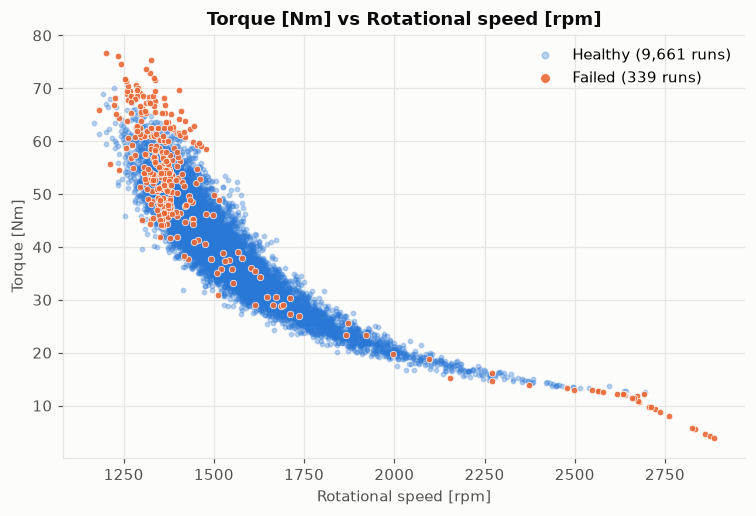

In [15]:
plotter.scatter("Rotational speed [rpm]", "Torque [Nm]")

**Failures sit at the edges of the operating range, not in the middle.**

- Torque and speed move in opposite directions: the faster the spindle turns, the less torque it needs.
- Most failures cluster in the **top-left corner**, where a slow spindle is under heavy load. This is where overstrain, heat-dissipation and power failures happen.
- A second, smaller group sits at the **far bottom-right**: very high speed with very low torque.

**Takeaway:** watching torque and speed *together* is the clearest early-warning signal in this data.

### 2. Histogram: rotational speed

We use rotational speed because it is the only sensor column with a strong skew (see the numerical summary below).

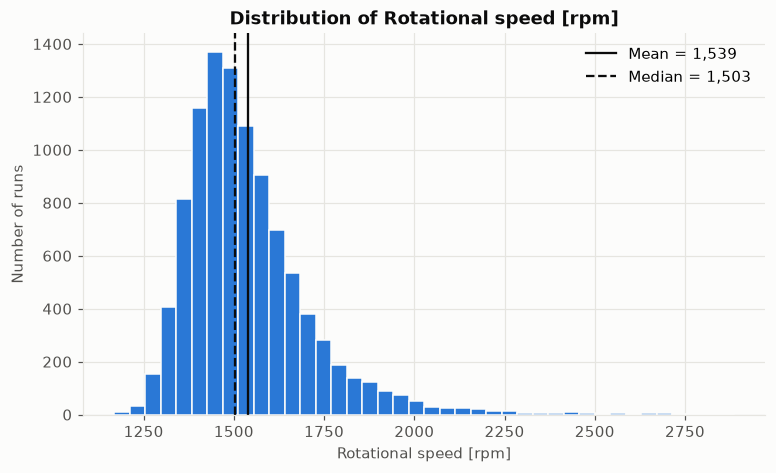

In [16]:
plotter.histogram("Rotational speed [rpm]")

**Spindle speed is right-skewed, so the median (1,503 rpm) is the better "typical" value, not the mean (1,539 rpm).**

Most runs sit between about 1,300 and 1,700 rpm. A thin tail of very fast runs, up to 2,886 rpm, pulls the mean to the right of the median. This agrees with the skew value in Person B's central tendency table.

### 3. Box-and-whisker plots: healthy vs failed runs

How to read a box:

- The box covers the middle 50% of runs (Q1 to Q3).
- The thick line is the median.
- The whiskers reach 1.5 × IQR.
- The dots are outliers.

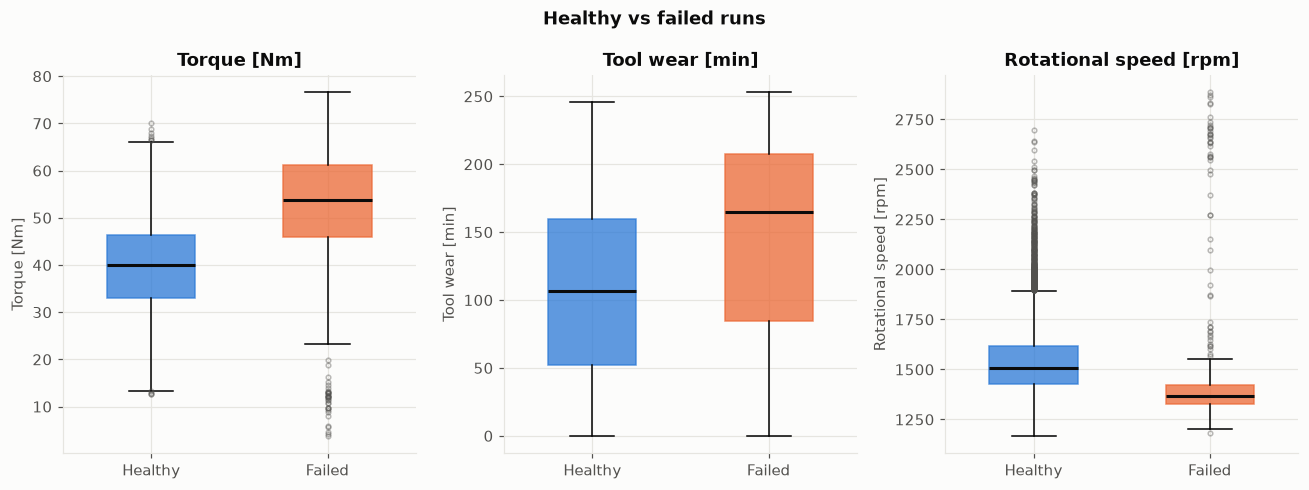

In [17]:
plotter.boxplots(["Torque [Nm]", "Tool wear [min]", "Rotational speed [rpm]"])

**Failed runs need more torque, use more-worn tools and spin slower.**

- **Torque:** the failed median is 53.7 Nm vs 39.9 Nm for healthy runs. The failed box sits almost entirely above the healthy one.
- **Tool wear:** the failed median is 165 min vs 107 min. Failures lean towards older tools.
- **Rotational speed:** the failed median is 1,365 rpm vs 1,507 rpm. The orange outliers above 2,000 rpm are the high-speed failures from the scatter plot.

**Takeaway:** torque separates healthy from failed runs more clearly than any other sensor.

### 4. Venn diagram: how failure modes overlap

This uses only the 339 failed runs. The method picks the three most common failure-mode flags automatically.

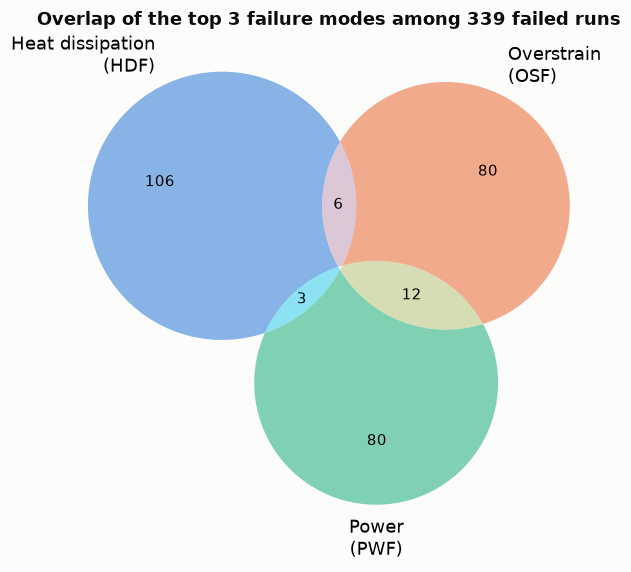

In [18]:
plotter.failure_mode_venn()

**Most failures have one clear cause, so a technician can be sent straight to the right fix.**

- **Heat dissipation (HDF)** is the largest group, with 106 failures on its own.
- Only 21 runs combine two of these modes. The most common pair is overstrain + power (12), and no run has all three.
- Tool wear (TWF, 46 runs) and random (RNF, 19 runs) failures are left out, because a Venn diagram is only readable with three sets.

**Why it matters:** the single yes/no `Machine failure` label hides this detail. The mode flags tell the maintenance team *what* to fix.

### 5. Numerical summary

#### Sensor readings

In [19]:
plotter.numerical_summary()

,count,mean,std,min,25%,50%,75%,max,skew
Air temperature [K],10000,300.00,2.00,295.3,298.3,300.1,301.5,304.5,0.11
Process temperature [K],10000,310.01,1.48,305.7,308.8,310.1,311.1,313.8,0.02
Rotational speed [rpm],10000,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0,1.99
Torque [Nm],10000,39.99,9.97,3.8,33.2,40.1,46.8,76.6,-0.01
Tool wear [min],10000,107.95,63.65,0.0,53.0,108.0,162.0,253.0,0.03


**The sensor data is complete and mostly symmetric. Only speed is skewed.**

- All 10,000 runs have every reading.
- The temperatures barely move (standard deviation 1.5–2 K).
- Tool wear spans the full range, from a new tool (0 min) to 253 min.
- Rotational speed is the only column with a strong skew (about 2.0), which is why the histogram above uses the median.

#### Failure rate by product type

In [20]:
plotter.failure_rate_by_type()

,runs,share_of_runs_pct,failures,failure_rate_pct
Type,,,,
L,6000,60.00,235,3.92
M,2997,29.97,83,2.77
H,1003,10.03,21,2.09


**Low-quality (L) products fail almost twice as often as high-quality (H) ones: 3.9% vs 2.1%.**

L products are also 60% of all runs, so they account for most failures: 235 of the 339.

**Takeaway:** prioritise inspection of L-grade runs.

### Challenge 7 summary

1. **Torque is the strongest single warning sign.** Failed runs have a median torque about 14 Nm higher than healthy runs.
2. **Failures live at the extremes:** slow and heavily loaded, or very fast and lightly loaded.
3. **Most failures have a single cause**, led by heat dissipation.
4. **L-grade products fail most often** (3.9%).